# Notebook 04: Learning-to-Rank for Matching

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

# Local imports
import sys
sys.path.insert(0, str(Path.cwd().parent / 'data'))
from ltr import load_ltr_model, evaluate_ltr, train_ltr, build_ltr_dataset, predict_ltr, load_donations, load_requests, load_ideal, load_similarities
from evaluation_common import haversine_km, item_group, is_ideal_match

OUT = Path('..') / 'data' / 'output'
RESULTS = OUT / 'results'


## 1. Load Baseline Results

In [2]:
with open(RESULTS / 'tuned_weights.json') as f:
    tuned_list = json.load(f)

with open(RESULTS / 'baselines.json') as f:
    baselines_list = json.load(f)

tuned = next(w for w in tuned_list if w.get('p_norm') == 0.9)
baselines = {b['system']: b for b in baselines_list}

print('Weighted baseline (tuned):', tuned['NDCG@5'])
print('Nearest baseline:', baselines['nearest']['NDCG@5'])
print('Random baseline:', baselines['random']['NDCG@5'])


Weighted baseline (tuned): 0.3883122742077121
Nearest baseline: 0.3704108546465939
Random baseline: 0.02151393421935633


## 2. Train & Evaluate Learning-to-Rank

In [3]:
model, scaler, X_test, y_test, groups_test, feat_df = train_ltr()
results = evaluate_ltr(model, scaler, X_test, y_test, groups_test, feat_df)
print(f'LTR Avg NDCG@5: {results["avg_ndcg@5"]:.4f}')
print(f'LTR Avg AP: {results["avg_ap"]:.4f}')
print('Feature importance:')
for k, v in sorted(results['feature_importance'].items(), key=lambda x: -x[1]):
    print(f'  {k}: {v:.4f}')


LTR Avg NDCG@5: 0.1433
LTR Avg AP: 0.1300
Feature importance:
  similarity: 0.5115
  proximity: 0.4747
  quantity_fit: 0.0076
  urgency: 0.0028
  seasonal: 0.0026
  reliability: 0.0008
  condition: 0.0000


D:\donation system\backend\venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
D:\donation system\backend\venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
D:\donation system\backend\venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
D:\donation system\backend\venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
D:\donation system\backend\venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
D:\donation system\backend\venv\Lib\site-packages\

## 3. Comparison with Baselines

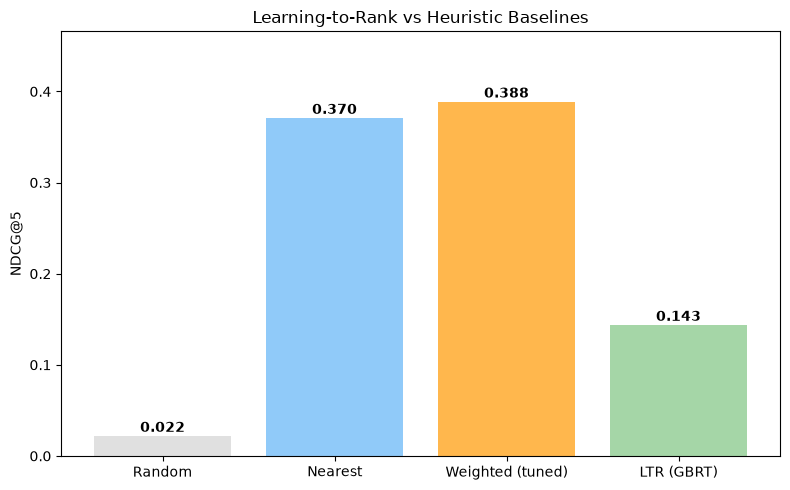

In [4]:
import matplotlib.pyplot as plt

methods = ['Random', 'Nearest', 'Weighted (tuned)', 'LTR (GBRT)']
scores = [
    baselines['random']['NDCG@5'],
    baselines['nearest']['NDCG@5'],
    tuned['NDCG@5'],
    results['avg_ndcg@5']
]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, scores, color=['#e0e0e0', '#90caf9', '#ffb74d', '#a5d6a7'])
plt.ylabel('NDCG@5')
plt.title('Learning-to-Rank vs Heuristic Baselines')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{score:.3f}', ha='center', fontweight='bold')
plt.ylim(0, max(scores) * 1.2)
plt.tight_layout()
plt.show()


## 4. Feature Importance

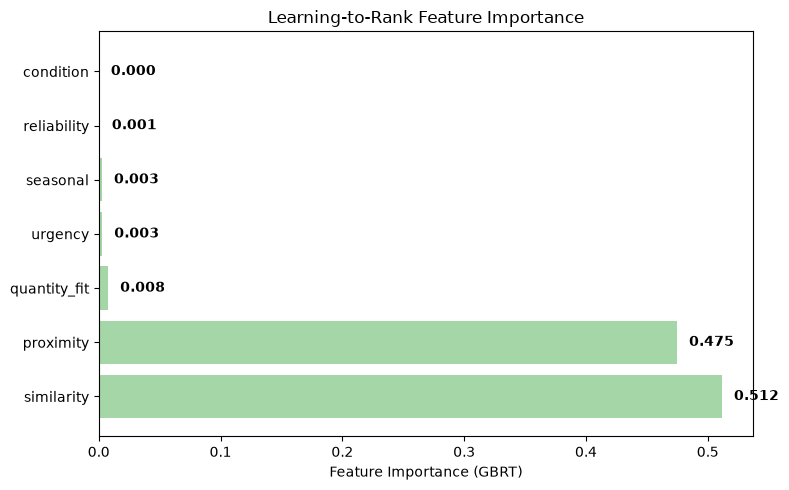

In [5]:
import matplotlib.pyplot as plt

fi = results['feature_importance']
features = list(fi.keys())
importances = list(fi.values())

# Sort
sorted_pairs = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)
features = [p[0] for p in sorted_pairs]
importances = [p[1] for p in sorted_pairs]

plt.figure(figsize=(8, 5))
bars = plt.barh(features, importances, color='#a5d6a7')
plt.xlabel('Feature Importance (GBRT)')
plt.title('Learning-to-Rank Feature Importance')
for bar, imp in zip(bars, importances):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{imp:.3f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()
